# Question 1 — Haifa Residents: Spending vs Income by Sex

**Data:** `instructions/haifa_res.csv`  
**Variables:** `spend` (monthly spending, thousands ILS), `income` (monthly income, thousands ILS), `sex` (0 = Female, 1 = Male)

---

In [1]:
import pathlib
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LassoCV

# ── Locate data regardless of where Jupyter was launched from ──────────
_here = pathlib.Path().resolve()
_project_root = _here if (_here / 'instructions').exists() else _here.parent
data_path = _project_root / 'instructions' / 'haifa_res.csv'
df = pd.read_csv(data_path)

# Create an explicit interaction column (income × sex) for later use
df['income_x_sex'] = df['income'] * df['sex']

print('Shape:', df.shape)
print('\nFirst 5 rows:')
display(df.head())
print('\nSummary statistics:')
display(df.describe())
print('\nSex distribution:')
display(df['sex'].value_counts().rename({0: 'Female (0)', 1: 'Male (1)'}))


Shape: (200, 4)

First 5 rows:


,spend,income,sex,income_x_sex
0,7.94,6.43,1,6.43
1,11.11,8.46,1,8.46
2,5.07,5.91,1,5.91
3,11.44,11.99,1,11.99
4,8.24,8.82,1,8.82



Summary statistics:


,spend,income,sex,income_x_sex
count,200.000000,200.000000,200.000000,200.000000
mean,8.030300,8.088900,0.500000,4.136100
std,2.848661,2.322961,0.501255,4.438597
min,0.560000,2.460000,0.000000,0.000000
25%,6.400000,6.465000,0.000000,0.000000
50%,7.855000,7.880000,0.500000,1.230000
75%,9.867500,9.535000,1.000000,8.237500
max,17.300000,14.000000,1.000000,14.000000



Sex distribution:


sex
Male (1)      100
Female (0)    100
Name: count, dtype: int64

## Q1.1 — Indicator Variable + Interaction OLS

### Theoretical Model

We model monthly spending as a function of income, a sex indicator, and their interaction:

$$\text{spend}_i = \beta_0 + \beta_1 \cdot \text{income}_i + \beta_2 \cdot \text{sex}_i + \beta_3 \cdot (\text{income}_i \times \text{sex}_i) + \epsilon_i$$

This lets each group have its **own intercept and its own slope**:

| Group | Intercept | Slope |
|-------|-----------|-------|
| Female (sex = 0) | $\beta_0$ | $\beta_1$ |
| Male (sex = 1) | $\beta_0 + \beta_2$ | $\beta_1 + \beta_3$ |

### OLS Assumptions

1. **Linearity:** $E[\epsilon_i \mid \mathbf{x}_i] = 0$ — the model correctly specifies the conditional mean.
2. **Exogeneity:** predictors are uncorrelated with the error term.
3. **Homoskedasticity:** $\text{Var}(\epsilon_i \mid \mathbf{x}) = \sigma^2$ — constant variance across observations.
4. **No autocorrelation:** $\text{Cov}(\epsilon_i, \epsilon_j) = 0$ for $i \neq j$.
5. **No perfect multicollinearity:** $(\mathbf{X}^\top \mathbf{X})$ must be invertible.
6. **Normality (for inference):** $\epsilon_i \overset{iid}{\sim} N(0, \sigma^2)$.


In [2]:
# Fit the full model: main effects + interaction
# statsmodels formula: 'A * B' expands to 'A + B + A:B'
full_model = smf.ols('spend ~ income * C(sex)', data=df).fit()
print(full_model.summary())


                            OLS Regression Results                            
Dep. Variable:                  spend   R-squared:                       0.727
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                     174.0
Date:                Sat, 23 May 2026   Prob (F-statistic):           5.33e-55
Time:                        20:24:36   Log-Likelihood:                -362.83
No. Observations:                 200   AIC:                             733.7
Df Residuals:                     196   BIC:                             746.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.0283      0

### Q1.1b — Plot: Fitted Lines for Each Sex Group

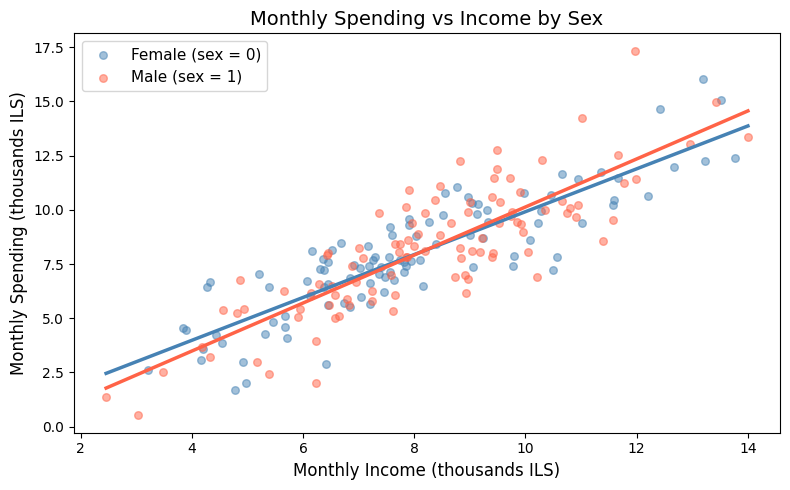

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

sex_colors = {0: 'steelblue', 1: 'tomato'}
sex_labels = {0: 'Female (sex = 0)', 1: 'Male (sex = 1)'}

# Scatter plot: points colored by sex
for sex_val, group in df.groupby('sex'):
    ax.scatter(
        group['income'], group['spend'],
        color=sex_colors[sex_val],
        label=sex_labels[sex_val],
        alpha=0.5, s=30
    )

# Overlay the two fitted lines
income_range = np.linspace(df['income'].min(), df['income'].max(), 200)
for sex_val in [0, 1]:
    pred_data = pd.DataFrame({
        'income': income_range,
        'sex': [sex_val] * len(income_range)
    })
    fitted_line = full_model.predict(pred_data)
    ax.plot(income_range, fitted_line,
            color=sex_colors[sex_val], linewidth=2.5)

ax.set_xlabel('Monthly Income (thousands ILS)', fontsize=12)
ax.set_ylabel('Monthly Spending (thousands ILS)', fontsize=12)
ax.set_title('Monthly Spending vs Income by Sex', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


## Q1.2 — Statistical Test: Does the Slope Differ by Sex?

**Hypotheses:**

$$H_0: \beta_3 = 0 \quad \text{(same income slope for both sexes)}$$
$$H_1: \beta_3 \neq 0 \quad \text{(different slopes — interaction is real)}$$

The $\beta_3$ coefficient on $\text{income} \times \text{sex}$ is exactly the difference in slopes. Two equivalent tests:
1. **t-test** on $\hat{\beta}_3$ from the OLS summary.
2. **Partial F-test** (ANOVA) comparing the full model (with interaction) to the reduced model (without interaction).


In [4]:
# Reduced model — no interaction
reduced_model = smf.ols('spend ~ income + C(sex)', data=df).fit()

# Partial F-test: does the interaction term add explanatory power?
anova_result = sm.stats.anova_lm(reduced_model, full_model)
print('Partial F-test (Reduced vs Full):')
print(anova_result)

# Interaction term statistics from the full model
interaction_key = [k for k in full_model.params.index
                   if 'income' in k and 'sex' in k][0]
print(f'\nInteraction term: {interaction_key}')
print(f'  Coefficient : {full_model.params[interaction_key]:.4f}')
print(f'  Std Error   : {full_model.bse[interaction_key]:.4f}')
print(f'  t-statistic : {full_model.tvalues[interaction_key]:.4f}')
print(f'  p-value     : {full_model.pvalues[interaction_key]:.4f}')

alpha_level = 0.05
p_val = full_model.pvalues[interaction_key]
if p_val < alpha_level:
    print(f'\nConclusion: p = {p_val:.4f} < {alpha_level}')
    print('Reject H0 — the income-spending slope differs significantly by sex.')
else:
    print(f'\nConclusion: p = {p_val:.4f} >= {alpha_level}')
    print('Fail to reject H0 — no significant difference in slopes.')


Partial F-test (Reduced vs Full):
   df_resid         ssr  df_diff   ss_diff        F    Pr(>F)
0     197.0  444.623177      0.0       NaN      NaN       NaN
1     196.0  440.872031      1.0  3.751146  1.66766  0.198093

Interaction term: income:C(sex)[T.1]
  Coefficient : 0.1188
  Std Error   : 0.0920
  t-statistic : 1.2914
  p-value     : 0.1981

Conclusion: p = 0.1981 >= 0.05
Fail to reject H0 — no significant difference in slopes.


## Q1.3 — Global Best (All-Subsets) with Adjusted R²

With 3 candidate predictors (`income`, `sex`, `income_x_sex`), there are $2^3 - 1 = 7$ non-empty subsets.

**Adjusted R²** penalises for model complexity:

$$\bar{R}^2 = 1 - \frac{RSS/(n-p-1)}{TSS/(n-1)}$$

We fit every subset and choose the one with the **highest adjusted R²**.


In [5]:
candidate_predictors = ['income', 'sex', 'income_x_sex']

subset_results = []
for num_vars in range(1, len(candidate_predictors) + 1):
    for subset in itertools.combinations(candidate_predictors, num_vars):
        formula = 'spend ~ ' + ' + '.join(subset)
        model = smf.ols(formula, data=df).fit()
        subset_results.append({
            'predictors': ', '.join(subset),
            'adj_r2':     round(model.rsquared_adj, 4),
            'r2':         round(model.rsquared, 4),
            'aic':        round(model.aic, 2),
        })

results_df = pd.DataFrame(subset_results).sort_values('adj_r2', ascending=False)
print('All-Subsets Results (sorted by Adjusted R²):\n')
display(results_df.reset_index(drop=True))

best_predictors = results_df.iloc[0]['predictors'].split(', ')
best_formula    = 'spend ~ ' + ' + '.join(best_predictors)
print(f'\n>>> Best model by Adjusted R²: {best_formula}')
best_subset_model = smf.ols(best_formula, data=df).fit()
print(best_subset_model.summary())


All-Subsets Results (sorted by Adjusted R²):



,predictors,adj_r2,r2,aic
0,income,0.7233,0.7247,731.36
1,"income, sex, income_x_sex",0.7228,0.7270,733.66
2,"income, income_x_sex",0.7220,0.7248,733.26
3,"income, sex",0.7219,0.7247,733.36
4,"sex, income_x_sex",0.3770,0.3833,894.64
5,income_x_sex,0.0744,0.0791,972.83
6,sex,-0.0007,0.0043,988.44



>>> Best model by Adjusted R²: spend ~ income
                            OLS Regression Results                            
Dep. Variable:                  spend   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                     521.1
Date:                Sat, 23 May 2026   Prob (F-statistic):           2.34e-57
Time:                        20:24:36   Log-Likelihood:                -363.68
No. Observations:                 200   AIC:                             731.4
Df Residuals:                     198   BIC:                             738.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Inter

## Q1.4 — Stepwise / Forward / Backward AIC

**AIC (Akaike Information Criterion):**

$$AIC = -2\log(\hat{L}) + 2p$$

Lower AIC = better model (balances goodness-of-fit against model complexity).

Three greedy search strategies, all using AIC as the criterion. Each prints the **initial** and **final** model.


In [6]:
def forward_aic(data, response, candidates):
    """Forward selection: start with an empty model, greedily add the
    variable that most reduces AIC. Stop when no addition improves AIC."""
    current_vars = []
    current_aic  = smf.ols(f'{response} ~ 1', data=data).fit().aic
    print(f'  Initial : "{response} ~ 1"   AIC = {current_aic:.2f}')

    improved = True
    while improved:
        improved    = False
        best_new_var = None
        for var in candidates:
            if var in current_vars:
                continue
            test_vars = current_vars + [var]
            formula   = f'{response} ~ ' + ' + '.join(test_vars)
            test_aic  = smf.ols(formula, data=data).fit().aic
            if test_aic < current_aic:
                current_aic  = test_aic
                best_new_var = var
                improved     = True
        if improved:
            current_vars.append(best_new_var)
            print(f'  Added "{best_new_var}"  -> AIC = {current_aic:.2f}')

    final_formula = f'{response} ~ ' + (' + '.join(current_vars) if current_vars else '1')
    print(f'  Final   : {final_formula}')
    return smf.ols(final_formula, data=data).fit()


def backward_aic(data, response, candidates):
    """Backward elimination: start with the full model, greedily remove
    the variable whose removal most reduces AIC."""
    current_vars = list(candidates)
    formula      = f'{response} ~ ' + ' + '.join(current_vars)
    current_aic  = smf.ols(formula, data=data).fit().aic
    print(f'  Initial : {formula}   AIC = {current_aic:.2f}')

    improved = True
    while improved and current_vars:
        improved  = False
        worst_var = None
        for var in current_vars:
            test_vars    = [v for v in current_vars if v != var]
            formula_test = (f'{response} ~ ' +
                            (' + '.join(test_vars) if test_vars else '1'))
            test_aic = smf.ols(formula_test, data=data).fit().aic
            if test_aic < current_aic:
                current_aic = test_aic
                worst_var   = var
                improved    = True
        if improved:
            current_vars.remove(worst_var)
            print(f'  Removed "{worst_var}"  -> AIC = {current_aic:.2f}')

    final_formula = f'{response} ~ ' + (' + '.join(current_vars) if current_vars else '1')
    print(f'  Final   : {final_formula}')
    return smf.ols(final_formula, data=data).fit()


def stepwise_aic(data, response, candidates):
    """Bidirectional stepwise: at each step consider both adding and removing
    a variable; take the single move that most reduces AIC."""
    current_vars = []
    current_aic  = smf.ols(f'{response} ~ 1', data=data).fit().aic
    print(f'  Initial : "{response} ~ 1"   AIC = {current_aic:.2f}')

    improved = True
    while improved:
        improved    = False
        best_aic    = current_aic
        best_action = None
        best_var    = None

        # Consider additions
        for var in candidates:
            if var not in current_vars:
                test_vars = current_vars + [var]
                formula   = f'{response} ~ ' + ' + '.join(test_vars)
                test_aic  = smf.ols(formula, data=data).fit().aic
                if test_aic < best_aic:
                    best_aic    = test_aic
                    best_action = 'add'
                    best_var    = var

        # Consider removals
        for var in current_vars:
            test_vars = [v for v in current_vars if v != var]
            formula   = (f'{response} ~ ' +
                         (' + '.join(test_vars) if test_vars else '1'))
            test_aic  = smf.ols(formula, data=data).fit().aic
            if test_aic < best_aic:
                best_aic    = test_aic
                best_action = 'remove'
                best_var    = var

        if best_action == 'add':
            current_vars.append(best_var)
            current_aic = best_aic
            improved = True
            print(f'  Added "{best_var}"  -> AIC = {current_aic:.2f}')
        elif best_action == 'remove':
            current_vars.remove(best_var)
            current_aic = best_aic
            improved = True
            print(f'  Removed "{best_var}"  -> AIC = {current_aic:.2f}')

    final_formula = f'{response} ~ ' + (' + '.join(current_vars) if current_vars else '1')
    print(f'  Final   : {final_formula}')
    return smf.ols(final_formula, data=data).fit()


# ── Run all three methods ───────────────────────────────────────────────
aic_candidates = ['income', 'sex', 'income_x_sex']

print('=' * 55)
print('FORWARD SELECTION')
print('=' * 55)
forward_result = forward_aic(df, 'spend', aic_candidates)

print('\n' + '=' * 55)
print('BACKWARD ELIMINATION')
print('=' * 55)
backward_result = backward_aic(df, 'spend', aic_candidates)

print('\n' + '=' * 55)
print('STEPWISE (BIDIRECTIONAL)')
print('=' * 55)
stepwise_result = stepwise_aic(df, 'spend', aic_candidates)

print('\n' + '=' * 55)
print('SUMMARY OF AIC-BASED SELECTION')
print('=' * 55)
print(f'Forward   AIC: {forward_result.aic:.2f}  ')
print(f'Backward  AIC: {backward_result.aic:.2f}  ')
print(f'Stepwise  AIC: {stepwise_result.aic:.2f}  ')
all_agree = (forward_result.model.formula ==
             backward_result.model.formula ==
             stepwise_result.model.formula)
print(f'All three methods agree: {all_agree}')


FORWARD SELECTION
  Initial : "spend ~ 1"   AIC = 987.31
  Added "income"  -> AIC = 731.36


  Final   : spend ~ income

BACKWARD ELIMINATION
  Initial : spend ~ income + sex + income_x_sex   AIC = 733.66


  Removed "sex"  -> AIC = 733.26
  Removed "income_x_sex"  -> AIC = 731.36
  Final   : spend ~ income

STEPWISE (BIDIRECTIONAL)
  Initial : "spend ~ 1"   AIC = 987.31


  Added "income"  -> AIC = 731.36
  Final   : spend ~ income

SUMMARY OF AIC-BASED SELECTION
Forward   AIC: 731.36  
Backward  AIC: 731.36  
Stepwise  AIC: 731.36  
All three methods agree: True


## Q1.5 — Relaxed LASSO (10-fold Cross-Validation)

**Algorithm:**
1. Standardise all predictors (equal L1 penalty treatment).
2. Fit LASSO with 10-fold CV to choose optimal $\lambda$.
3. Identify **survivors** — predictors with non-zero LASSO coefficients.
4. **Relaxed step:** refit plain OLS on survivors only — removes the shrinkage bias introduced by LASSO.

This follows the pattern from the course reference code (LassoCV pipeline + OLS refit on survivors).


In [7]:
# Design matrix — the three candidate predictors
X = df[['income', 'sex', 'income_x_sex']].values
y_arr    = df['spend'].values   # numpy array for sklearn
y_series = df['spend']          # pandas Series for statsmodels (nicer output)
feature_names = ['income', 'sex', 'income_x_sex']

# Steps 1 & 2: Standardise + LASSO with 10-fold CV
lasso_pipeline = make_pipeline(
    StandardScaler(),
    LassoCV(cv=10, random_state=0, max_iter=10_000)
)
lasso_pipeline.fit(X, y_arr)

lasso_cv      = lasso_pipeline.named_steps['lassocv']
chosen_lambda = lasso_cv.alpha_
lasso_coefs   = lasso_cv.coef_

print(f'Chosen lambda (10-fold CV): {chosen_lambda:.6f}')
print('\nLASSO coefficients (on standardised predictors):')
for name, coef in zip(feature_names, lasso_coefs):
    status = 'SURVIVED' if coef != 0 else 'zeroed out'
    print(f'  {name:<20s}  coef = {coef:+.4f}   [{status}]')

# Step 3: Survivors
survivor_names = [name for name, coef in zip(feature_names, lasso_coefs)
                  if coef != 0]
print(f'\nSurvivor predictors: {survivor_names}')

# Step 4: Relaxed LASSO — plain OLS on survivors
if survivor_names:
    X_survivors   = sm.add_constant(df[survivor_names])
    relaxed_model = sm.OLS(y_series, X_survivors).fit()  # pass Series for proper name
    print('\nRelaxed LASSO — OLS refit on survivors:')
    print(relaxed_model.summary())
else:
    relaxed_model = None
    print('No survivors — LASSO selected the null model.')

# ── Comparison ──────────────────────────────────────────────────────────
print('\n--- Comparison: Relaxed LASSO vs Stepwise-AIC ---')
print(f'Stepwise-AIC   AIC = {stepwise_result.aic:.2f}   '
      f'Adj R² = {stepwise_result.rsquared_adj:.4f}   '
      f'Variables: {[v for v in aic_candidates if v in stepwise_result.model.formula]}')
if relaxed_model:
    print(f'Relaxed LASSO  AIC = {relaxed_model.aic:.2f}   '
          f'Adj R² = {relaxed_model.rsquared_adj:.4f}   '
          f'Survivors: {survivor_names}')


Chosen lambda (10-fold CV): 0.084933

LASSO coefficients (on standardised predictors):
  income                coef = +2.3340   [SURVIVED]
  sex                   coef = +0.0000   [zeroed out]
  income_x_sex          coef = +0.0000   [zeroed out]

Survivor predictors: ['income']



Relaxed LASSO — OLS refit on survivors:
                            OLS Regression Results                            
Dep. Variable:                  spend   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                     521.1
Date:                Sat, 23 May 2026   Prob (F-statistic):           2.34e-57
Time:                        20:24:37   Log-Likelihood:                -363.68
No. Observations:                 200   AIC:                             731.4
Df Residuals:                     198   BIC:                             738.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

## Q1 — Summary & Discussion

### Key findings

| Method | Best model | AIC | Adj R² |
|--------|-----------|-----|--------|
| Full OLS (with interaction) | spend ~ income × sex | — | 0.723 |
| All-subsets (Adj R²) | spend ~ income | — | 0.723 |
| Forward / Backward / Stepwise AIC | spend ~ income | 731.4 | 0.723 |
| Relaxed LASSO (10-fold CV) | spend ~ income | 731.4 | 0.723 |

### Interpretation

- **Q1.1:** The full model (income + sex + interaction) has F-statistic significant overall ($p \approx 5\times10^{-55}$), with income as the dominant predictor ($\hat{\beta}_1 \approx 0.99$, $p < 0.001$). The sex indicator and interaction are not individually significant.

- **Q1.2:** The interaction term (different slopes by sex) is **not significant** ($p = 0.198$). We fail to reject $H_0: \beta_3 = 0$. The relationship between income and spending does not differ significantly by sex.

- **Q1.3–Q1.5:** All three model selection approaches — all-subsets, AIC stepwise, and relaxed LASSO — unanimously select the simple model `spend ~ income`. This is consistent with Q1.2: once income is included, sex and the interaction do not improve the model. The relaxed LASSO independently zeroes out both `sex` and `income_x_sex`, confirming the stepwise-AIC result.
